In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import re
import warnings

from plotly.tools import mpl_to_plotly
import plotly.io as pio
from matplotlib import pyplot as plt
from tracker.iou import *

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
def load_subj(subj):
    """
    Load a subject's data from folder. The subject's data is stored in a JSON file, a csv file, and a txt file
    """
    
    p2json = os.path.join("data",subj.lower(), "trackers.json")
    p2centroids = os.path.join("data",subj.lower(), "centroids.txt")
    with open(p2json, 'r') as f:
        subj_trackers = json.load(f)
    
    with open(p2centroids, 'r') as f:
        subj_centroids = np.array(eval(f.readline()))
    subj_long_dfs = pd.read_csv(os.path.join("data", subj.lower(), "long_dfs.csv"), index_col="frame") 
    subj_long_dfs.index = subj_long_dfs.index.astype(int)

    subj_trackers = {int(k): v for k, v in subj_trackers.items()}

    return subj_trackers, subj_long_dfs, subj_centroids

In [4]:
def generate_merge_summarize(trackers, dfs):
    tmp_summarize = generate_summarize(trackers)
    tmp_trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
    for i in range(len(tmp_summarize)):
        tmp_df = tmp_summarize.iloc[i]
        tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, dfs, trackers)
        tmp_trackers_type_df.loc[len(tmp_trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
        
    tmp_merged_summarize = pd.merge(tmp_summarize, tmp_trackers_type_df, on="num")
    return tmp_merged_summarize

In [5]:
def trackers2fine(trackers, dfs):
    tmp_merge_summarize = generate_merge_summarize(trackers, dfs)
    split_from_df = pd.concat([split_from(i, tmp_merge_summarize) for i in range(len(tmp_merge_summarize))], ignore_index=True)
    split_from_df = split_from_df.loc[split_from_df.is_split == True]
    tmp_all_num = []
    for i in range(len(split_from_df)):
        nex_num = split_from_df.iloc[i].nex_num
        diff = split_from_df.iloc[i]['difference']
        nex_start = split_from_df.iloc[i]["nex_start"]
        this_num = split_from_df.iloc[i].this_num
        tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])
        for i,j in zip(nex_start, diff):
            if j != 0:
                tmp_df.loc[len(tmp_df)] = [this_num, i]
        tmp_all_num.append(tmp_df)
    # print(tmp_all_num[0])
    if len(tmp_all_num) == 0:
        tmp_new_trackers = trackers
    elif len(tmp_all_num) >= 1:
        critical_split_df = pd.concat(tmp_all_num, ignore_index=True)
        tmp_new_trackers = {}
        ini_indx = 0
        for i in range(len(trackers)):
            if i not in critical_split_df.tracker_num.values:
                tmp_new_trackers[ini_indx] = trackers[i]
                ini_indx += 1
            else:
                split_result = split_trackers(i, critical_split_df, trackers)
                for j in split_result:
                    tmp_new_trackers[ini_indx] = j
                    ini_indx += 1

    tmp_new_summarize = generate_merge_summarize(tmp_new_trackers, dfs)
        
    merge_to_df = pd.concat([merge_to(i, tmp_new_summarize) for i in range(len(tmp_new_summarize))], ignore_index=True)
    merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
    tmp_all_num = []
    for i in range(len(merge_to_df)):
        diff = merge_to_df.iloc[i]['difference']
        nex_start = merge_to_df.iloc[i]["nex_end"]
        this_num = merge_to_df.iloc[i].this_num

        tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

        for i,j in zip(nex_start, diff):
            if j != 0:
                tmp_df.loc[len(tmp_df)] = [this_num, i]
        tmp_all_num.append(tmp_df)
    # print(tmp_all_num)
        
    if len(tmp_all_num) == 0:
        tmp_new_trackers_2 = tmp_new_trackers
    elif len(tmp_all_num) >= 1:
        critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
        critical_merge_df.split_frame += 1
        tmp_new_trackers_2 = {}
        ini_indx = 0
        for i in range(len(tmp_new_trackers)):
            if i not in critical_merge_df.tracker_num.values:
                tmp_new_trackers_2[ini_indx] = tmp_new_trackers[(i)]
                ini_indx += 1
            else:
                split_result = split_trackers(i, critical_merge_df, tmp_new_trackers)
                for j in split_result:
                    tmp_new_trackers_2[ini_indx] = j
                    ini_indx += 1
    # new_summarize_2 = generate_summarize(new_trackers_2)

    tmp_new_summarize2 = generate_merge_summarize(tmp_new_trackers_2, dfs)

    return tmp_new_trackers_2, tmp_new_summarize2

In [6]:
def find_worms(ini_indx,summarize, banned_list = np.array([])):
    worms = []
    for i in range(len(ini_indx)):
        tmp_worm, banned_list = simple_find_nex(ini_indx[i], summarize, banned_list)
        if new_summarize.loc[ini_indx[i]].start_frame > 300:
            tmp_worm_prev, banned_list = simple_find_prev(ini_indx[i], summarize, banned_list)
            tmp_worm = np.concatenate((tmp_worm_prev[:-1], tmp_worm))
        worms.append(tmp_worm)
    return worms

        

In [7]:
def diagnosis_worms(worms, summarize, centroid, dfs):
    """
    Diagnosis the worms
    """
    new_worms = []
    for i in range(len(worms)):
        tmp_worm = np.array([k for k in worms[i] if k != -1])
        if summarize.loc[tmp_worm[0]].start_frame > 300:
            print("worm %d start frame > 300" % i)
            continue
        if summarize.loc[tmp_worm[-1]].end_frame < np.max(long_dfs.index):
            if np.linalg.norm(summarize.loc[tmp_worm[-1]].end_centroids - centroid) < 850:
                print("worm %d end frame < max frame" % i)
                continue
        
        new_worms.append(tmp_worm)
    return new_worms
                

In [8]:
def worm2df(worm, trackers):
    dfs = []
    for i in worm:
        tmp_df = pd.DataFrame(trackers[i]['centroids'], columns=["x", "y"])
        tmp_frames = pd.Series(range(trackers[i]['start_frame'], trackers[i]['end_frame']+1), name="frames")
        tmp_df = pd.concat([tmp_frames, tmp_df], axis=1)
        tmp_trackers_id = pd.Series([i]*len(tmp_df), name="trackers_id")
        tmp_df = pd.concat([tmp_trackers_id, tmp_df], axis=1)
        tmp_ovals = pd.DataFrame(trackers[i]['ovals'], columns=["width", "height"])
        tmp_df = pd.concat([tmp_df, tmp_ovals], axis=1)
        tmp_df.set_index("frames", inplace=True)
        dfs.append(tmp_df)
    return pd.concat(dfs, axis=0)
def plot_worm(worm, centroid, trackers):
    fig,ax = plt.subplots(figsize=(15,10))
    for i,j in enumerate(worm):
        ax.plot(*np.array(trackers[j]['centroids']).T, label=j)
        if i < len(worm) - 1:
            last_centroid = trackers[j]['centroids'][-1]
            next_centroid = trackers[worm[i+1]]['centroids'][0]
            ax.plot([last_centroid[0], next_centroid[0]], [last_centroid[1], next_centroid[1]], 'k--')
    
    ax.set_xlim(0, 3072)
    ax.set_ylim(0, 2048)
    
    ax.legend()
    plotly_fig = mpl_to_plotly(fig)
    plotly_fig.add_shape(type="circle", 
                        xref="x", yref="y",
                        x0=centroid[0]-925, y0=centroid[1]-925,
                        x1=centroid[0]+925, y1=centroid[1]+925,
                        line_color="black",)
    return plotly_fig


def write_results(subj, worms, trackers, centroid):
    os.path.isdir("./final_results") or os.mkdir("./final_results")
    p2subj = os.path.join("final_results", subj.lower())
    os.path.isdir(p2subj) and shutil.rmtree(p2subj)
    os.path.isdir(p2subj) or os.mkdir(p2subj)
    p2imgs = os.path.join(p2subj, "imgs")
    os.path.isdir(p2imgs) or os.mkdir(p2imgs)
    p2csvs = os.path.join(p2subj, "csvs")
    os.path.isdir(p2csvs) or os.mkdir(p2csvs)
    
    for i,j in enumerate(worms):
        tmp_fig = plot_worm(j, centroid, trackers)
        # tmp_fig.write_image(os.path.join(p2imgs, "worms_%d.png" % (i)))
        pio.write_html(tmp_fig, file=os.path.join(p2imgs, "worms_%d.html" % (i)), auto_open=True)
        tmp_df = worm2df(j, trackers)
        tmp_df.to_csv(os.path.join(p2csvs, "worms_%d.csv" % (i)))
    
    
    

In [9]:
def return_folder_name(date):
    """
    Return the folder name of the data
    """
    all_folders_name = os.listdir("data")
    return [i for i in all_folders_name if date in i]

In [108]:
np.linalg.norm( new_trackers[435]['centroids'][-1]  - centroid)

918.4307916139522

n2_trained11_3.18


<Axes: xlabel='frame'>

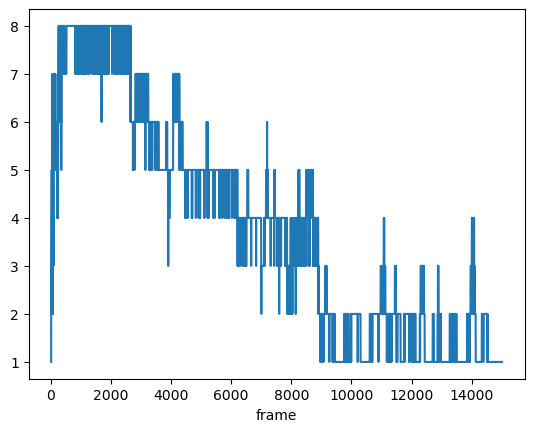

In [195]:
analyze_folder = return_folder_name("3.18")[8]
print(analyze_folder)
all_trackers, long_dfs, centroid = load_subj(analyze_folder)
new_trackers, new_summarize = trackers2fine(all_trackers, long_dfs)
long_dfs.groupby('frame').size().plot()

In [196]:
all_ini = find_initial(long_dfs, 8, new_summarize)
ini_indx = all_ini.sort_values(by='start_frame').num.values
print(len(ini_indx))

8


In [197]:
worms = find_worms(ini_indx, new_summarize)
new_worms = diagnosis_worms(worms, new_summarize, centroid, long_dfs)

$[10] all path banned
$[8] all path banned


In [202]:
tmp_dict = {}
for roots, dirs, files in os.walk("./final_results"):
    if "csvs" in roots:
        tmp_dict[roots.split(os.sep)[-2]] = len(files)
        

In [204]:
"naive"

'naive'

In [205]:
new_dict = {"naive": [], "trained": []}

In [206]:
for k,i in tmp_dict.items():
    if "naive" in k:
        new_dict["naive"].append(i)
    elif "trained" in k:
        new_dict["trained"].append(i)

In [209]:
sum(new_dict['trained'])

141

In [198]:
write_results(analyze_folder, new_worms, new_trackers, centroid)

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:645: UserWarning:

Looks like the annotation(s) you are trying 
to draw lies/lay outside the given figure size.

Therefore, the resulting Plotly figure may not be 
large enough to view the full text. To adjust 
the size of the figure, use the 'width' and 
'height' keys in the Layout

In [152]:
new_summarize.loc[new_worms[7]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
49,49,20,1508,1488,"[1420.0, 1114.0, 9.0, 6.0]","[1532.0, 936.0, 17.0, 11.0]","[1424.3643410852712, 1117.1162790697674]","[1541.4753623188406, 939.6579710144928]",appear,merge,"([], [])","([50], [1509])"
50,50,1509,1559,50,"[1522.0, 936.0, 27.0, 20.0]","[1535.0, 910.0, 9.0, 39.0]","[1534.3198198198197, 943.1456456456456]","[1538.9133986928105, 927.5375816993464]",merge,split,"([10, 49], [1508, 1508])","([51, 17], [1560, 1560])"
17,17,1560,4098,2538,"[1535.0, 910.0, 9.0, 17.0]","[1712.0, 625.0, 20.0, 9.0]","[1539.0, 917.002976190476]","[1721.298076923077, 628.9551282051282]",split,merge,"([50], [1559])","([18], [4099])"
18,18,4099,4406,307,"[1712.0, 607.0, 19.0, 27.0]","[1630.0, 556.0, 26.0, 25.0]","[1719.247619047619, 622.2555555555555]","[1639.3996509598603, 566.2739965095985]",merge,disappear,"([17, 16], [4098, 4098])","([], [])"
19,19,4415,4483,68,"[1630.0, 556.0, 22.0, 25.0]","[1598.0, 549.0, 33.0, 11.0]","[1638.3804713804714, 566.1531986531986]","[1615.5956006768188, 554.5126903553299]",appear,split,"([], [])","([58, 20], [4484, 4484])"
20,20,4484,4549,65,"[1597.0, 549.0, 19.0, 7.0]","[1556.0, 548.0, 19.0, 7.0]","[1605.7845117845118, 552.4040404040404]","[1564.0936329588012, 551.501872659176]",split,merge,"([19], [4483])","([22], [4550])"
22,22,4550,4573,23,"[1541.0, 549.0, 32.0, 13.0]","[1536.0, 547.0, 40.0, 13.0]","[1556.2736030828514, 553.9267822736031]","[1555.521276595745, 553.5336879432624]",merge,split,"([21, 20], [4549, 4549])","([23, 41], [4574, 4574])"
23,23,4574,5895,1321,"[1536.0, 552.0, 20.0, 8.0]","[1517.0, 480.0, 9.0, 17.0]","[1545.5333333333333, 555.4962962962962]","[1520.856540084388, 487.8691983122363]",split,disappear,"([22], [4573])","([], [])"
32,32,5904,6519,615,"[1517.0, 474.0, 8.0, 19.0]","[1474.0, 519.0, 13.0, 13.0]","[1519.693486590038, 483.39846743295016]","[1479.2745098039215, 525.678431372549]",appear,merge,"([], [])","([42], [6520])"
42,42,6520,6582,62,"[1467.0, 516.0, 18.0, 17.0]","[1444.0, 486.0, 22.0, 21.0]","[1474.2638888888887, 524.0496031746031]","[1457.2697495183045, 497.40269749518296]",merge,split,"([32, 41], [6519, 6519])","([43, 36], [6583, 6583])"


In [73]:
new_worms


[array([11, 12, 16, 19]),
 array([17, 18, 59, 60, 72, 80, 88, 91, 93, 99]),
 array([10, 33, 48]),
 array([37, 39, 50]),
 array([15, 18, 59, 42, 43, 44, 51, 52, 54, 56, 57, 66, 67, 68, 73, 76, 77,
        82]),
 array([30, 31, 45, 51, 53, 54, 55, 57, 58, 67, 70]),
 array([29, 31, 34, 43, 63]),
 array([ 9, 21, 22, 23, 24, 25, 35, 36, 38, 40, 41, 46, 47, 49, 61, 65, 71])]

In [34]:
new_summarize.loc[worms[1]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
85,85,4265,4275,10,"[1908.0, 1391.0, 10.0, 12.0]","[1904.0, 1397.0, 9.0, 5.0]","[1911.8969696969696, 1395.3696969696969]","[1908.2592592592591, 1399.125925925926]",appear,disappear,"([], [])","([], [])"
86,86,4324,4337,13,"[1870.0, 1404.0, 14.0, 6.0]","[1860.0, 1408.0, 13.0, 6.0]","[1876.1633986928105, 1406.7124183006536]","[1867.5942028985503, 1411.050724637681]",appear,disappear,"([], [])","([], [])"
87,87,4346,4382,36,"[1859.0, 1409.0, 6.0, 13.0]","[1853.0, 1435.0, 9.0, 12.0]","[1861.2875816993464, 1414.4967320261435]","[1856.3081761006288, 1440.6729559748426]",appear,disappear,"([], [])","([], [])"
88,88,4384,4397,13,"[1853.0, 1436.0, 8.0, 11.0]","[1856.0, 1446.0, 5.0, 11.0]","[1855.833333333333, 1441.090909090909]","[1857.7013888888887, 1451.0]",appear,disappear,"([], [])","([], [])"
89,89,4399,4409,10,"[1856.0, 1445.0, 10.0, 14.0]","[1860.0, 1453.0, 6.0, 13.0]","[1858.53216374269, 1451.4152046783624]","[1862.405797101449, 1459.1304347826087]",appear,disappear,"([], [])","([], [])"
90,90,4448,4522,74,"[1874.0, 1470.0, 10.0, 14.0]","[1877.0, 1494.0, 7.0, 14.0]","[1877.8397435897436, 1476.852564102564]","[1879.8076923076924, 1499.3012820512818]",appear,disappear,"([], [])","([], [])"
91,91,4524,4545,21,"[1877.0, 1494.0, 11.0, 12.0]","[1881.0, 1476.0, 9.0, 10.0]","[1880.514619883041, 1498.1286549707602]","[1883.7551020408164, 1480.5850340136053]",appear,disappear,"([], [])","([], [])"
92,92,4547,4565,18,"[1881.0, 1475.0, 9.0, 11.0]","[1881.0, 1476.0, 7.0, 8.0]","[1883.847222222222, 1479.5138888888887]","[1883.608974358974, 1479.75]",appear,disappear,"([], [])","([], [])"
93,93,4567,4576,9,"[1881.0, 1474.0, 7.0, 10.0]","[1884.0, 1468.0, 7.0, 13.0]","[1883.94, 1478.78]","[1887.590909090909, 1474.909090909091]",appear,disappear,"([], [])","([], [])"
94,94,4579,4616,37,"[1885.0, 1466.0, 6.0, 15.0]","[1895.0, 1438.0, 8.0, 11.0]","[1887.6339869281044, 1472.830065359477]","[1898.1382113821137, 1443.2764227642276]",appear,disappear,"([], [])","([], [])"


In [28]:
write_results(analyze_folder, new_worms, new_trackers, centroid)

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



In [23]:
def conn_disappear_prev_test(tmp_df, merge_trackers_summarize):
    tmp_start_frame = tmp_df.start_frame
    tmp_start_centroids = tmp_df.start_centroids
    tmp_start_bbox = tmp_df.start_bbox

    indx_frame = (merge_trackers_summarize.end_frame < tmp_start_frame) & (np.abs(merge_trackers_summarize.end_frame - tmp_start_frame) <= 100) & (merge_trackers_summarize.right_type == "disappear")

    tmp_prev_df = merge_trackers_summarize.loc[indx_frame]
    tmp_indx = tmp_prev_df.index.to_numpy()
    # print(tmp_prev_df)
    if len(tmp_prev_df) == 0:
        return "can't find"
    else:
        distance_series = pd.Series({i: np.linalg.norm(np.array(tmp_prev_df.loc[i].end_centroids) - np.array(tmp_start_centroids)) for i in tmp_indx}, name="distance")
        diff_frames_series = pd.Series({i: np.abs(tmp_prev_df.loc[i].end_frame - tmp_start_frame) for i in tmp_indx}, name="diff_frames")
        overlapping_series = pd.Series({i: iou(tmp_prev_df.loc[i].end_bbox, tmp_start_bbox) > 0 for i in tmp_indx}, name="is_overlapping")
        # mean_velocity_series = pd.Series({i: np.linalg.norm(np.array(tmp_prev_df.loc[i].end_centroids) - np.array(tmp_start_centroids)) / np.abs(tmp_prev_df.loc[i].end_frame - tmp_start_frame) < 5 for i in tmp_indx}, name="mean_velocity")
        tmp_df = pd.concat([tmp_prev_df, overlapping_series, diff_frames_series,mean_velocity_series, distance_series], axis=1)
        tmp_df = tmp_df.loc[tmp_df.distance / tmp_df.diff_frames < 5]
        if len(tmp_df) == 0:
            return "can't find"
        tmp_df.sort_values(by=["distance", "diff_frames"], inplace=True)
        return tmp_df
        

        # for i in range(len(tmp_prev_df)):
        #     if iou(tmp_prev_df.iloc[i].end_bbox, tmp_start_bbox) > 0:
        #         return tmp_prev_df.iloc[i].num
        #     if np.linalg.norm(np.array(tmp_prev_df.iloc[i].start_centroids) - np.array(tmp_start_centroids)) / np.abs(tmp_prev_df.iloc[i].start_frame - tmp_start_frame) < 5:
        #         return tmp_prev_df.iloc[i].num
        # return "can't find"

In [22]:
conn_disappear_prev_test(new_summarize.loc[29], new_summarize)

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next,is_overlapping,diff_frames,mean_velocity,distance
26,26,1019,1034,15,"[1971.0, 1235.0, 7.0, 9.0]","[1970.0, 1239.0, 6.0, 12.0]","[1973.827160493827, 1238.0987654320986]","[1972.1347517730496, 1245.0567375886524]",appear,disappear,"([], [])","([], [])",False,62,True,226.900103
25,25,997,1010,13,"[1979.0, 1248.0, 7.0, 15.0]","[1973.0, 1242.0, 12.0, 8.0]","[1981.9285714285716, 1254.6190476190477]","[1978.26, 1245.7]",appear,disappear,"([], [])","([], [])",False,86,True,232.911146


In [21]:
conn_disappear_prev(new_summarize.loc[29], new_summarize)

26

In [70]:
tmp_df = conn_disappear_prev(new_summarize.loc[46], new_summarize)
tmp_df['mean_velocity'] = tmp_df['distance'] / tmp_df['diff_frames']
tmp_df

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next,is_overlapping,diff_frames,mean_velocity,distance
13,13,493,539,46,"[1621.0, 1064.0, 10.0, 6.0]","[1624.0, 1062.0, 9.0, 7.0]","[1625.737588652482, 1066.2553191489362]","[1627.6821705426355, 1065.0387596899225]",appear,disappear,"([], [])","([], [])",False,5,2.557118,12.785590
11,11,451,463,12,"[1613.0, 1066.0, 9.0, 8.0]","[1610.0, 1066.0, 12.0, 7.0]","[1616.9858156028367, 1070.3120567375886]","[1615.75, 1069.7152777777776]",appear,disappear,"([], [])","([], [])",False,81,0.168930,13.683369
10,10,175,451,276,"[1861.0, 1068.0, 7.0, 13.0]","[1856.0, 1162.0, 7.0, 12.0]","[1864.251572327044, 1072.8742138364778]","[1860.1056910569105, 1166.8373983739837]",appear,disappear,"([], [])","([], [])",False,93,2.858295,265.821396


In [27]:
ini_indx

array([106, 108, 107, 129])

In [25]:
new_worms

[array([  0,   3,  10,  46,  49,  63,  66,  67,  77,  78,  80, 106, 154])]

In [66]:
worms

[array([  0,   3,  10,  46,  49,  68,  77,  78,  80, 106, 154]),
 array([ 85,  87,  90,  93,  96,  97,  98, 100, 102, 108, 110, 111, 114,
        115, 116, 117, 119, 120, 121, 122, 123, 124, 130, 131, 132, 133,
        139, 140, 142, 146, 149, 153, 157, 159, 165]),
 array([  5,  32,  35,  37,  39,  41,  45,  50,  52,  55,  57,  59,  62,
         69, 103, 105, 107, 109, 112, 113, 118, 125, 126, 127, 128, 134,
        135, 136, 137, 138, 141, 143, 144, 145, 147, 148, 150, 151, 152,
        155, 156, 158, 160, 161, 162, 163, 164, 166, 167, 168, 170, 172,
        173, 174, 175, 176, 177, 179, 180, 183, 184]),
 array([ -1, 105, 129,  -1])]

In [68]:
for w in worms:
    if 12 in w:
        print(w)

In [13]:
new_summarize.loc[12]

num                                                      12
start_frame                                             463
end_frame                                               509
durations                                                46
start_bbox                      [1861.0, 1169.0, 6.0, 15.0]
end_bbox                        [1866.0, 1198.0, 5.0, 11.0]
start_centroids    [1862.7608695652173, 1176.0434782608695]
end_centroids         [1868.503875968992, 1202.84496124031]
left_type                                            appear
right_type                                        disappear
left_prev                                          ([], [])
right_next                                         ([], [])
Name: 12, dtype: object

In [14]:
simple_find_nex(12, new_summarize, np.array([]))

(array([12, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 65,
        66, 67, 77, 72, 73]),
 array([12., 14., 15., 16., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
        27., 28., 31., 65., 67., 72., 73.]))

In [15]:
t = []
find_all_nex(10, new_summarize, t, banned_list=[])
t

[   this_num  nex_num right_type
 0        10       12  disappear,
    this_num  nex_num right_type
 0        12       14  disappear,
    this_num  nex_num right_type
 0        14       15  disappear,
    this_num  nex_num right_type
 0        15       16  disappear,
    this_num  nex_num right_type
 0        16       18  disappear,
    this_num  nex_num right_type
 0        18       19  disappear,
    this_num  nex_num right_type
 0        19       20  disappear,
    this_num  nex_num right_type
 0        20       21  disappear,
    this_num  nex_num right_type
 0        21       22  disappear,
    this_num  nex_num right_type
 0        22       23  disappear,
    this_num  nex_num right_type
 0        23       24  disappear,
    this_num  nex_num right_type
 0        24       25  disappear,
    this_num  nex_num right_type
 0        25       26  disappear,
    this_num  nex_num right_type
 0        26       27  disappear,
    this_num  nex_num right_type
 0        27       28  disapp

In [16]:
conn_disappear_next(new_summarize.loc[10], new_summarize)

12

In [17]:
conn_disappear_next_test(new_summarize.loc[10], new_summarize)

NameError: name 'conn_disappear_next_test' is not defined

In [18]:
write_results(analyze_folder, new_worms, new_trackers, centroid)

NameError: name 'new_worms' is not defined

In [ ]:
def store2csvs(worms, trackers, p2sfcsvs):
    """
    Store the worms' data to csv files
    """

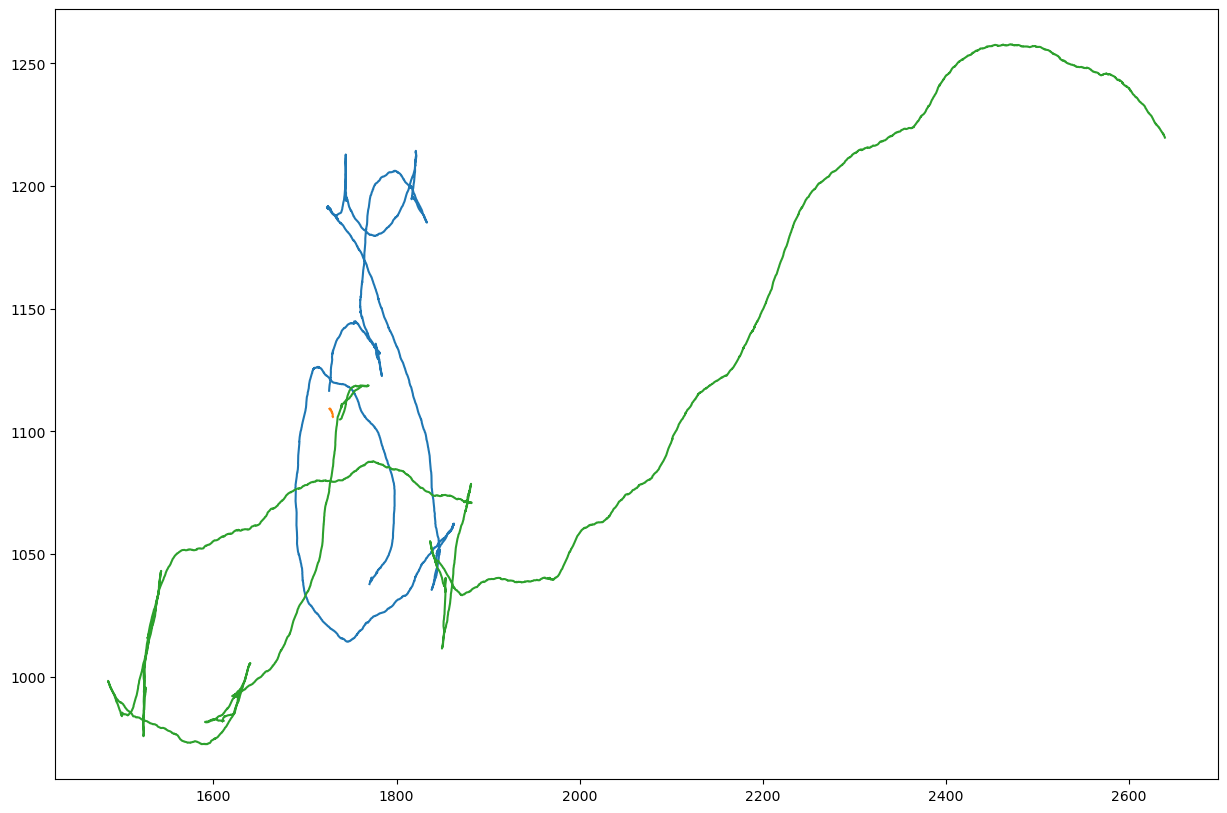

In [ ]:
fig

In [ ]:
new_trackers[worms[0][0]]

{'start_frame': 18,
 'end_frame': 2028,
 'bboxes': [[1953.0, 1007.0, 5.0, 11.0],
  [1953.0, 1006.0, 5.0, 12.0],
  [1953.0, 1006.0, 5.0, 11.0],
  [1953.0, 1005.0, 6.0, 12.0],
  [1953.0, 1005.0, 6.0, 12.0],
  [1953.0, 1003.0, 7.0, 15.0],
  [1953.0, 1002.0, 7.0, 16.0],
  [1953.0, 1002.0, 7.0, 15.0],
  [1953.0, 1001.0, 7.0, 17.0],
  [1953.0, 1001.0, 7.0, 16.0],
  [1953.0, 1001.0, 7.0, 16.0],
  [1953.0, 1001.0, 7.0, 16.0],
  [1952.0, 1001.0, 8.0, 16.0],
  [1951.0, 1001.0, 10.0, 14.0],
  [1949.0, 1001.0, 12.0, 11.0],
  [1947.0, 1001.0, 14.0, 11.0],
  [1947.0, 1000.0, 14.0, 12.0],
  [1947.0, 1000.0, 14.0, 11.0],
  [1947.0, 1000.0, 14.0, 11.0],
  [1947.0, 998.0, 14.0, 14.0],
  [1947.0, 997.0, 13.0, 14.0],
  [1947.0, 996.0, 13.0, 14.0],
  [1946.0, 995.0, 14.0, 15.0],
  [1945.0, 995.0, 15.0, 14.0],
  [1944.0, 994.0, 14.0, 13.0],
  [1944.0, 994.0, 16.0, 14.0],
  [1942.0, 994.0, 18.0, 14.0],
  [1941.0, 994.0, 16.0, 13.0],
  [1941.0, 994.0, 18.0, 13.0],
  [1941.0, 994.0, 16.0, 13.0],
  [1939.0, 994

In [ ]:
new_worms

[array([17]),
 array([19, 20, 46]),
 array([18, 20, 43]),
 array([13, 14, 29, 30, 31, 37, 38, 39, 41, 42, 64]),
 array([45, 50, 51, 54]),
 array([ 0,  1,  5,  6, 10, 11, 12, 14, 21, 32, 37, 35, 39, 40, 42, 62]),
 array([ 4,  5,  6,  7, 11, 48]),
 array([ 5,  8, 23, 24, 25, 16, 30, 33, 47]),
 array([22, 23, 27, 28, 44])]

In [ ]:
new_summarize.loc[new_worms[1][-1]]

num                                                     60
start_frame                                           3252
end_frame                                             5744
durations                                             2492
start_bbox                     [1457.0, 617.0, 17.0, 12.0]
end_bbox                        [1109.0, 340.0, 6.0, 11.0]
start_centroids    [1464.3859649122808, 623.4649122807018]
end_centroids      [1111.7460317460316, 344.6190476190476]
left_type                                            split
right_type                                       disappear
left_prev                                   ([59], [3251])
right_next                                        ([], [])
Name: 60, dtype: object

In [ ]:
np.linalg.norm(new_summarize.loc[new_worms[6][-1]].end_centroids - centroid)

920.582889890979

In [ ]:
for i in worms:
    print(i)

$[12] all path banned
[11 12 16 19]
[17 18 59 42 43 63]
[10 33 48]
[37 39 50]
[15 18 59 60 72 80 88 91 93 99]
[30 31 45 51 52 54 56 57 58 67 68 73 76 77 82]
[29 31 34 43 44 51 53 54 55 57 66 67 70]
[ 9 -1]


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [ ]:

worms

[array([11, -1]),
 array([17, 18, 59, -1]),
 array([10, -1]),
 array([37, -1]),
 array([15, 18, 59, -1]),
 array([30, 31, -1]),
 array([29, 31, -1]),
 array([ 9, -1])]

In [ ]:
new_summarize.loc[[worms[1][-3]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
91,91,12766,13600,834,"[1823.0, 874.0, 6.0, 10.0]","[1990.0, 715.0, 10.0, 12.0]","[1826.030303030303, 877.6969696969696]","[1993.0114942528733, 719.8563218390805]",appear,disappear,"([], [])","([], [])"


In [ ]:
banned_list = np.array([])

worms = []
for i in range(len(ini_indx)):
    tmp_worm, banned_list = simple_find_nex(ini_indx[i], new_summarize, banned_list)
    if new_summarize.loc[ini_indx[i]].start_frame > 300:
        tmp_worm_prev, banned_list = simple_find_prev(ini_indx[i], new_summarize, banned_list)
        tmp_worm = np.concatenate((tmp_worm_prev[:-1], tmp_worm))
    worms.append(tmp_worm)


$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [ ]:
for i in worms:
    print(i)

[11 12 16 19]
[17 18 59 60 72 80 88 91 93 99]
[10 33 48]
[37 39 50]
[15 18 59 42 43 44 51 53 54 56 57 58 67 70]
[30 31 34 43 63]
[29 31 45 51 52 54 55 57 66 67 68 73 76 77 82]
[ 9 -1]


In [ ]:
for j,i in enumerate(worms):
    if i[0] == -1:
        print("worms{} has bad start".format(j+1))
    elif i[-1] == -1:
        print("worms{} has bad end".format(j+1))

worms8 has bad end


In [ ]:
find_worms(ini_indx, new_summarize)

$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

[array([11, 12, 16, 19]),
 array([17, 18, 59, 42, 43, 44, 51, 53, 54, 55, 57, 58, 67, 68, 73, 76, 77,
        82]),
 array([10, 33, 48]),
 array([37, 39, 50]),
 array([15, 18, 59, 60, 72, 80, 88, 91, 93, 99]),
 array([30, 31, 34, 43, 63]),
 array([29, 31, 45, 51, 52, 54, 56, 57, 66, 67, 70]),
 array([ 9, -1])]

In [ ]:
banned_list = np.array([])
for i in range(len(all_ini)):
    exec("worm{}, banned_list = simple_find_nex(ini_indx[{}], new_summarize,  banned_list)".format(i+1, i))
    if new_summarize.loc[ini_indx[i]].start_frame <= 300:
        continue
    else:
        exec("worm_prev{}, banned_list = simple_find_prev(ini_indx[{}], new_summarize,  banned_list)".format(i+1, i))
        exec("worm{} = np.concatenate((worm_prev{}[:-1], worm{}))".format(i+1, i+1, i+1))

$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [ ]:
worm1[-1]

array([11, 12, 16, 19])

In [ ]:
new_summarize.loc[[worm3[1]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
33,33,1237,5488,4251,"[1766.0, 1107.0, 10.0, 7.0]","[1005.0, 1620.0, 13.0, 8.0]","[1771.0666666666666, 1110.5666666666666]","[1010.9230769230768, 1623.423076923077]",appear,disappear,"([], [])","([], [])"


In [ ]:
worm8[-1]

-1

In [ ]:
new_summarize.loc[[worm7[-1]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
70,70,8780,9803,1023,"[1515.0, 1833.0, 7.0, 20.0]","[1266.0, 1835.0, 8.0, 8.0]","[1518.0633608815426, 1842.732782369146]","[1268.65873015873, 1838.063492063492]",split,disappear,"([67], [8779])","([], [])"


In [ ]:
np.linalg.norm(np.array(new_summarize.loc[worm7[-1]].end_centroids) - centroid)

920.716151486145

In [ ]:
new_summarize.loc[worm3]

KeyError: '[-1] not in index'

In [ ]:
for j in range(1,11):
    print("worm{}".format(j),eval("worm{}".format(j)))

worm1 [147]
worm2 [ 95  96 104 105 106 128 129 150 151]
worm3 [  0   6   9  10  11  56  57  58  59  60  64  66  68  70  80  96  97 101
 103 105 112 121 122 134 123 136 137 142 143 156 158]
worm4 [ -1  12  23  16  42  37  39  47  48  44  50  51  53  54  62  69  72  73
  74  76  84  85  86  83  89  90 126 109 110 107 115 116 117 118 120 131
 132 141 142 155]
worm5 [ -1   4  41  42  43  52  59  61  65  66  67  70  78  79 108 117 119 120
 149 150 153]
worm6 [22 23 24 25 26 27 15 29 38 39 -1]
worm7 [ -1  20  31  46  53  55  63  69  71  73  75  76  81  85  86  87  91  93
  94  99 100 101 114 115 133 134 135 136 130 132 154]
worm8 [ 13  25  14  27  28  29  30  31  32 113 124 152]
worm9 [ -1  17  18  19  34  35  36  45  57  77  79 125 126 127 128 148]
worm10 [ -1   8  10  33  34  21  36  82  86  87  88  89  92  93  98  99 102 110
 111 121 140 156 157]


In [ ]:
merge_new_summarize.loc[worm10[2]]

num                                                      10
start_frame                                             564
end_frame                                               574
durations                                                10
start_bbox                     [1727.0, 1039.0, 29.0, 18.0]
end_bbox                       [1723.0, 1042.0, 31.0, 21.0]
start_centroids    [1738.5564625850338, 1046.9986394557825]
end_centroids      [1735.6609929078013, 1049.4652482269505]
left_type                                             merge
right_type                                            split
left_prev                              ([8, 9], [563, 563])
right_next                           ([11, 33], [575, 575])
Name: 10, dtype: object